In [1]:
import numpy as np
import pandas as pd

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [2]:
with open("../data/alllines.txt", "r", encoding="utf-8") as file:
    text = file.read()

In [3]:
print(text[:500])

"ACT I"
"SCENE I. London. The palace."
"Enter KING HENRY, LORD JOHN OF LANCASTER, the EARL of WESTMORELAND, SIR WALTER BLUNT, and others"
"So shaken as we are, so wan with care,"
"Find we a time for frighted peace to pant,"
"And breathe short-winded accents of new broils"
"To be commenced in strands afar remote."
"No more the thirsty entrance of this soil"
"Shall daub her lips with her own children's blood,"
"Nor more shall trenching war channel her fields,"
"Nor bruise her flowerets with the ar


In [4]:
text = text.lower()
lines = text.split("\n")

In [5]:
import re

# remove stage directions
text = re.sub(r'act\s+[ivx]+', '', text)
text = re.sub(r'scene\s+[ivx]+', '', text)

# remove "enter" and "exit"
text = re.sub(r'\benter\b', '', text)
text = re.sub(r'\bexit\b', '', text)

# remove extra spaces
text = re.sub(r'\s+', ' ', text)

text = text.strip()

In [6]:
print(text[:100])

"" ". london. the palace." " king henry, lord john of lancaster, the earl of westmoreland, sir walte


In [7]:
len(text)

4559080

In [8]:
len(text.split())

812933

In [9]:
# tokenize the text
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()
tokenizer.fit_on_texts(lines)

In [10]:
total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

Vocabulary Size: 25576


In [11]:
# create input sequences using list of tokens
input_sequences = []

for line in lines:
    
    token_list = tokenizer.texts_to_sequences([line])[0]
    
    for i in range(1, len(token_list)):
        
        n_gram_sequence = token_list[:i+1]
        input_sequences.append(n_gram_sequence)

In [12]:
len(input_sequences)
input_sequences[:10]

[[315, 3],
 [135, 3],
 [135, 3, 802],
 [135, 3, 802, 1],
 [135, 3, 802, 1, 571],
 [51, 88],
 [51, 88, 338],
 [51, 88, 338, 45],
 [51, 88, 338, 45, 397],
 [51, 88, 338, 45, 397, 5]]

In [13]:
# so our input sequences are of different lengths. We need to pad them to make them of the same length.
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# find maximum sequence length
# max_sequence_len = max([len(seq) for seq in input_sequences])
max_sequence_len=30
max_sequence_len

30

In [14]:
input_sequences = np.array(
    pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre')
)

In [15]:
input_sequences[:2]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0, 315,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0, 135,   3]], dtype=int32)

In [16]:
print(input_sequences.shape)

(709820, 30)


In [17]:
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

In [18]:
X.shape, y.shape

((709820, 29), (709820,))

In [19]:
# why not one-hot encoding ? it wast of memory and time. we can use sparse_categorical_crossentropy loss function which will take care of that for us.


In [20]:
# embedding
model = Sequential()
model.add(
    Embedding(
        input_dim=total_words,
        output_dim=100,
        input_shape=(max_sequence_len-1,)
    )
)
model.add(LSTM(150))
model.add(Dense(total_words, activation='softmax'))


c:\Users\brije\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
# compile the model
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 29, 100)        │     2,557,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 150)            │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25576)          │     3,861,976 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,570,176 (25.06 MB)

 Trainable params: 6,570,176 (25.06 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
print(X.shape)
print(y.shape)
print(total_words)
print(max_sequence_len)

(709820, 29)
(709820,)
25576
30


In [24]:
# model training
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Train shape: (638838, 29)
Validation shape: (70982, 29)


In [25]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "next_word_lstm_best.h5",
    monitor='val_loss',
    save_best_only=True
)

In [26]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=128,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/20
4991/4991 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.0500 - loss: 6.9083

4991/4991 ━━━━━━━━━━━━━━━━━━━━ 695s 139ms/step - accuracy: 0.0500 - loss: 6.9083 - val_accuracy: 0.0900 - val_loss: 6.3094
Epoch 2/20
4991/4991 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.0969 - loss: 6.0703

4991/4991 ━━━━━━━━━━━━━━━━━━━━ 794s 159ms/step - accuracy: 0.0969 - loss: 6.0703 - val_accuracy: 0.1040 - val_loss: 6.1203
Epoch 3/20
4991/4991 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.1116 - loss: 5.7536

4991/4991 ━━━━━━━━━━━━━━━━━━━━ 1193s 239ms/step - accuracy: 0.1116 - loss: 5.7536 - val_accuracy: 0.1096 - val_loss: 6.0623
Epoch 4/20
4991/4991 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.1223 - loss: 5.5088

4991/4991 ━━━━━━━━━━━━━━━━━━━━ 1153s 231ms/step - accuracy: 0.1223 - loss: 5.5088 - val_accuracy: 0.1142 - val_loss: 6.0616
Epoch 5/20
4991/4991 ━━━━━━━━━━━━━━━━━━━━ 1150s 230ms/step - accuracy: 0.1301 - loss: 5.3004 - val_accuracy: 0.1158 - val_loss: 6.1031
Epoch 6/20
4991/4991 ━━━━━━━━━━━━━━━━━━━━ 17855s 4s/step - accuracy: 0.1377 - loss: 5.1203 - val_accuracy: 0.1182 - val_loss: 6.1682
Epoch 7/20
4991/4991 ━━━━━━━━━━━━━━━━━━━━ 707s 142ms/step - accuracy: 0.1479 - loss: 4.9468 - val_accuracy: 0.1167 - val_loss: 6.2524


In [27]:
model.save("next_word_model.keras")

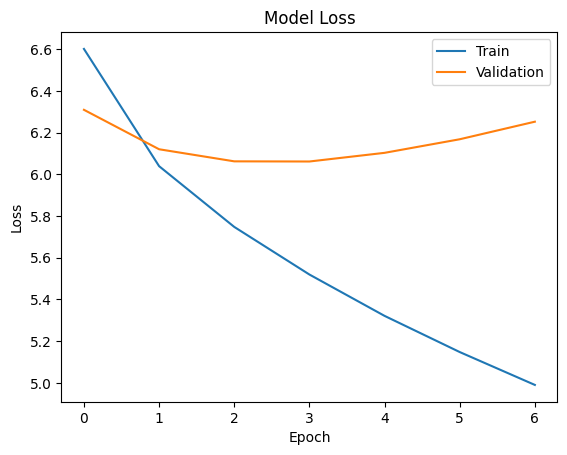

In [28]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.legend(["Train","Validation"])

plt.show()

In [29]:
import pickle

with open("tokenizer.pkl","wb") as f:
    pickle.dump(tokenizer,f)

In [43]:
def predict_next_words(text, model, tokenizer, max_sequence_len, top_k=5):

    token_list = tokenizer.texts_to_sequences([text])[0]

    if len(token_list) == 0:
        return []

    token_list = pad_sequences(
        [token_list],
        maxlen=max_sequence_len-1,
        padding='pre'
    )

    predictions = model.predict(token_list, verbose=0)[0]

    # get top K predictions
    top_indices = np.argsort(predictions)[-top_k:][::-1]

    results = []

    for index in top_indices:
        word = tokenizer.index_word.get(index, "Unknown")
        prob = predictions[index]
        results.append((word, float(prob)))

    return results

In [44]:
predict_next_words("king henry is", model, tokenizer, max_sequence_len)

[('the', 0.20557473599910736),
 ('a', 0.12356609106063843),
 ('my', 0.03151020035147667),
 ('and', 0.02952750399708748),
 ('his', 0.028673119843006134)]

In [47]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def generate_text(seed_text, next_words, model, tokenizer, max_sequence_len, temperature=1.0):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_sequence_len-1,
            padding='pre'
        )

        preds = model.predict(token_list, verbose=0)[0]

        # temperature scaling
        preds = np.log(preds + 1e-10) / temperature
        preds = np.exp(preds)
        preds = preds / np.sum(preds)

        predicted_index = np.random.choice(len(preds), p=preds)

        output_word = tokenizer.index_word.get(predicted_index, "")

        seed_text += " " + output_word

    return seed_text

In [49]:
generate_text(
    "king henry is",
    12,
    model,
    tokenizer,
    max_sequence_len,
    temperature=0.8
)

'king henry is the world in the world o antonio what would you be true'